# **CNN_waste_segregation_Khaleel_Husain**

# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [1]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1


In [2]:
# Import essential libraries

# Data Manipulation Packages
import numpy as np
import pandas as pd

# Data Visualization Packages
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

# Data Loading Packages
import zipfile
import os

# Data Preprocessing Packages
from collections import Counter

# Train-Test Split Packages
from sklearn.model_selection import train_test_split

# Encoding Categorical Labels (for one Hot Encoding)
from tensorflow.keras.utils import to_categorical

# Model Building Packages
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Model Training Packages
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
# EarlyStopping prevents wasting time if the model stops improving.
# ReduceLROnPlateau lowers the learning rate to help the model find the absolute best "bottom" of the loss function.

# Model Evaluation Packages
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Load the dataset.

In [3]:
# Load and unzip the dataset

# Loading the dataset
compressed_path = "data.zip"
extracted_path = "Dataset_Waste_Segregation/"

# Check if the zip file exists
if os.path.exists(compressed_path):
    # Unzip the dataset
    with zipfile.ZipFile(compressed_path, 'r') as zip_ref:
        if(os.path.exists(os.path.join(extracted_path, "data"))):
            # Check if the directory already exists
            print(f"Directory {extracted_path} already exists. Please remove it before extracting.")
            exit(1)
        else:
            zip_ref.extractall(extracted_path)
    print(f"Dataset successfully extracted to {extracted_path}")
else:
    print(f"Zip file not found at {compressed_path}. Please check the path.")

Directory Dataset_Waste_Segregation/ already exists. Please remove it before extracting.
Dataset successfully extracted to Dataset_Waste_Segregation/


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [4]:
# Create a function to load the raw images
def load_images(base_directory):
    processed_images = []
    category_labels = []

    # Iterate through each subfolder (each subfolder represents a class/label)
    for category_name in os.listdir(base_directory):
        category_path = os.path.join(base_directory, category_name)
        
        if os.path.isdir(category_path):
            print(f"Processing category: {category_name}...")
            image_count = 0
            
            for file_name in os.listdir(category_path):
                file_path = os.path.join(category_path, file_name)
                
                # Check for common image extensions
                if file_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                    try:
                        with Image.open(file_path) as raw_img:
                            # Standardize image size to 128x128
                            resized_img = raw_img.resize((128, 128))
                            
                            processed_images.append(np.array(resized_img))
                            category_labels.append(category_name)
                            image_count += 1
                    except Exception as e:
                        print(f"Could not load image {file_name}: {e}")

            print(f"Successfully loaded {image_count} images for '{category_name}'.")

    return np.array(processed_images), np.array(category_labels)

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [5]:
# Get the images and their labels

# Path to the main folder containing subfolders
base_directory = os.path.join(extracted_path, 'data')

# Get the images and their labels
images, labels = load_images(base_directory)

Processing category: Cardboard...
Successfully loaded 540 images for 'Cardboard'.
Processing category: Food_Waste...
Successfully loaded 1000 images for 'Food_Waste'.
Processing category: Glass...
Successfully loaded 750 images for 'Glass'.
Processing category: Metal...
Successfully loaded 1000 images for 'Metal'.
Processing category: Other...
Successfully loaded 1010 images for 'Other'.
Processing category: Paper...
Successfully loaded 1030 images for 'Paper'.
Processing category: Plastic...
Successfully loaded 2295 images for 'Plastic'.


In [6]:
# Length of images and labels
len(images), len(labels)

(7625, 7625)

In [7]:
all_categories = np.unique(labels)
print(f"The categories are: {all_categories}")

The categories are: ['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']


In [8]:
# Explore the dataset
for i, category in enumerate(all_categories):
    print(f"Category: {category}, Number of images: {np.sum(labels == category)}")

Category: Cardboard, Number of images: 540
Category: Food_Waste, Number of images: 1000
Category: Glass, Number of images: 750
Category: Metal, Number of images: 1000
Category: Other, Number of images: 1010
Category: Paper, Number of images: 1030
Category: Plastic, Number of images: 2295


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

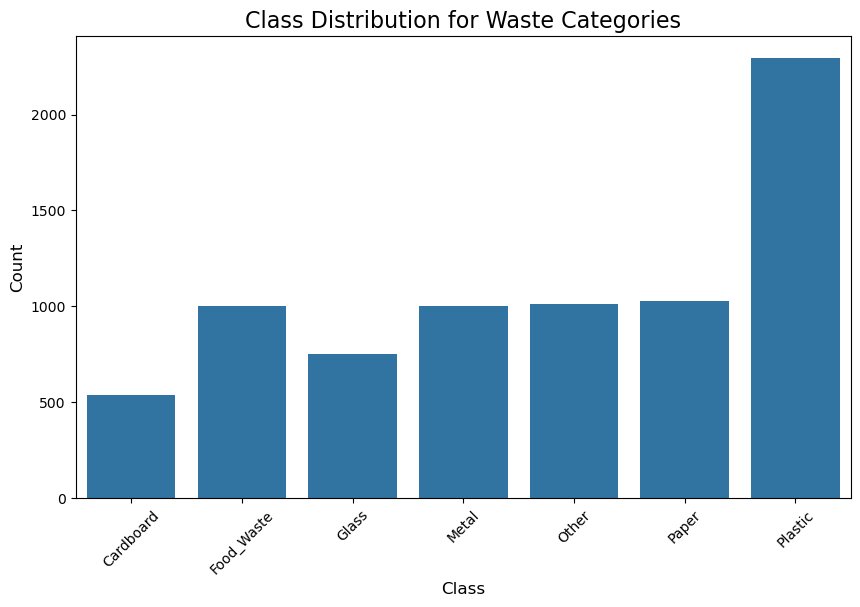

In [9]:
# Visualise Data Distribution

# Count the labels
number_of_labels = Counter(labels)

# Visualise Data Distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=list(number_of_labels.keys()), y=list(number_of_labels.values()))
plt.title("Class Distribution for Waste Categories", fontsize=16)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.show()

#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

Generating preview grid for 7 categories...


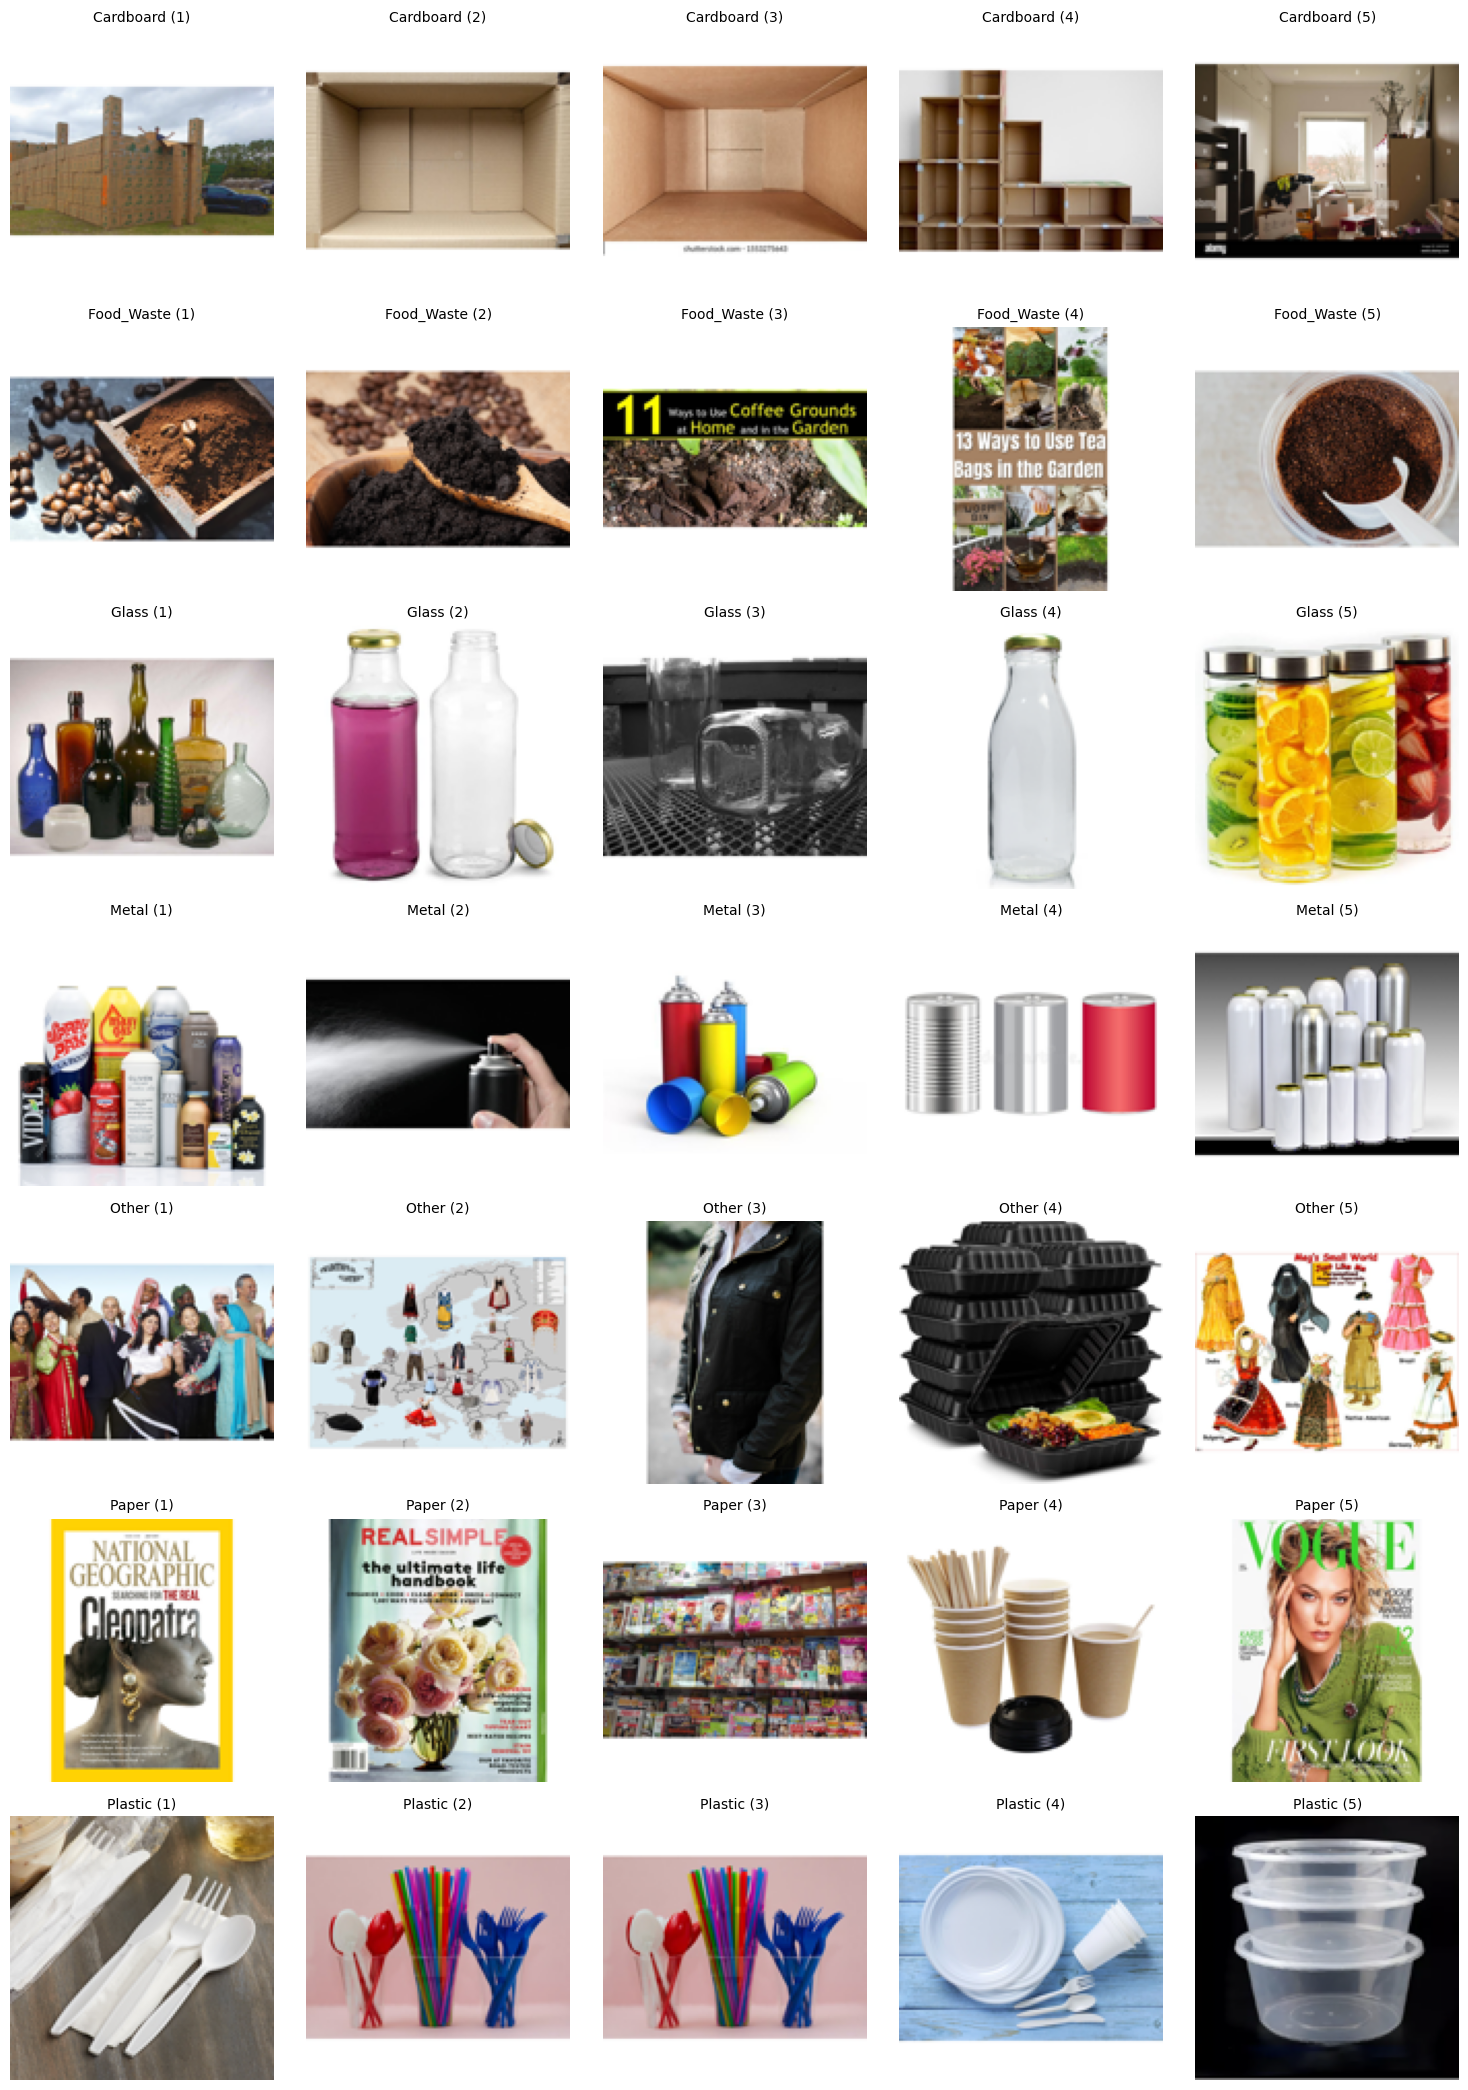

In [12]:
# Visualise Sample Images (across different labels)
max_images_per_class = 5
preview_collection = {}

# Gather sample images for each category
for category_name in os.listdir(base_directory):
    category_dir = os.path.join(base_directory, category_name)
    
    if os.path.isdir(category_dir):
        preview_collection[category_name] = []
        
        for file_name in os.listdir(category_dir):
            if file_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                file_path = os.path.join(category_dir, file_name)
                
                with Image.open(file_path) as raw_img:
                    # Uniform resizing for grid alignment
                    resized_sample = raw_img.resize((128, 128))
                    preview_collection[category_name].append(np.array(resized_sample))
                
                # Stop once we hit the desired number of samples for this class
                if len(preview_collection[category_name]) >= max_images_per_class:
                    break

# Plotting the visual grid
print(f"Generating preview grid for {len(preview_collection)} categories...")

num_categories = len(preview_collection)
plt.figure(figsize=(max_samples_per_class * 3, num_categories * 3))

for row_idx, (class_label, sample_list) in enumerate(preview_collection.items()):
    for col_idx, img_data in enumerate(sample_list):
        # Calculate grid position: (row index * total columns) + current column + 1
        subplot_position = (row_idx * max_samples_per_class) + col_idx + 1
        
        plt.subplot(num_categories, max_samples_per_class, subplot_position)
        plt.imshow(img_data)
        plt.title(f"{class_label} ({col_idx + 1})", fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [15]:
# Find the smallest and largest image dimensions from the data set

def minandmax_image_dimensions(base_directory):
    # Initialize boundaries with infinity for minimums and zero for maximums
    min_dims = (float('inf'), float('inf'))  # (width, height)
    max_dims = (0, 0)                        # (width, height)

    print(f"Scanning directory: {base_directory} for dimension extremes...")

    for folder_name in os.listdir(base_directory):
        class_path = os.path.join(base_directory, folder_name)
        
        if os.path.isdir(class_path):
            for file_name in os.listdir(class_path):
                if file_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                    image_path = os.path.join(class_path, file_name)
                    
                    try:
                        with Image.open(image_path) as current_img:
                            w, h = current_img.size
                            
                            # Update minimums
                            new_min_w = min(min_dims[0], w)
                            new_min_h = min(min_dims[1], h)
                            
                            # Update maximums
                            new_max_w = max(max_dims[0], w)
                            new_max_h = max(max_dims[1], h)

                            # Brief status update if a new extreme is found
                            if (new_min_w, new_min_h) != min_dims or (new_max_w, new_max_h) != max_dims:
                                min_dims = (new_min_w, new_min_h)
                                max_dims = (new_max_w, new_max_h)
                    
                    except Exception as error:
                        print(f"Skipping {file_name}: {error}")

    print(f"Scan complete. Smallest Dimension: {min_dims}, Largest Dimension: {max_dims}")
    return min_dims, max_dims

min_dimensions, max_dimensions = minandmax_image_dimensions(base_directory)

Scanning directory: Dataset_Waste_Segregation/data for dimension extremes...
Scan complete. Smallest Dimension: (256, 256), Largest Dimension: (256, 256)


In [17]:
# Resize the image dimensions
def resize_images(base_directory, output_path, target_size=(128, 128)):
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    
    for category_folder in os.listdir(base_directory):
        category_path = os.path.join(base_directory, category_folder)
        output_category_path = os.path.join(output_path, category_folder)
        
        if os.path.isdir(category_path):
            if not os.path.exists(output_category_path):
                os.makedirs(output_category_path)
            
            for filename in os.listdir(category_path):
                if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('.jpeg'):
                    img_path = os.path.join(category_path, filename)
                    output_img_path = os.path.join(output_category_path, filename)
                    
                    with Image.open(img_path) as img:
                        img_resized = img.resize(target_size)
                        img_resized.save(output_img_path)
    
    print(f"Images resized and saved to {output_path}")

output_path = os.path.join(extracted_path, 'resized_data')
resize_images(base_directory, output_path, target_size=(128, 128))

Images resized and saved to Dataset_Waste_Segregation/resized_data


**Why 128x128 resizing?**
1. *Computational Efficiency*: It provides the right balance, being small enough to train quickly on standard hardware (RAM/GPU) while remaining large enough to retain the textures and edges needed to distinguish glass from cardboard.

2. *Architectural Alignment*: CNNs use Pooling Layers that repeatedly halve dimensions (e.g., 128→64→32); using a power-of-2 ensures the math remains clean across deep layers without requiring complex padding.

3. *Improved Generalization*: Reducing the resolution slightly forces the model to focus on broad structural patterns (shapes and colors) rather than "memorizing" microscopic noise or specific scratches unique to a single training image.

In [18]:
# Get resized images and their labels
images, labels = load_images(output_path)
print(f"Loaded {len(images)} images with labels.")

Processing category: Cardboard...
Successfully loaded 540 images for 'Cardboard'.
Processing category: Food_Waste...
Successfully loaded 1000 images for 'Food_Waste'.
Processing category: Glass...
Successfully loaded 750 images for 'Glass'.
Processing category: Metal...
Successfully loaded 1000 images for 'Metal'.
Processing category: Other...
Successfully loaded 1010 images for 'Other'.
Processing category: Paper...
Successfully loaded 1030 images for 'Paper'.
Processing category: Plastic...
Successfully loaded 2295 images for 'Plastic'.
Loaded 7625 images with labels.


In [19]:
print(f"Resized images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Resized images shape: (7625, 128, 128, 3)
Labels shape: (7625,)


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [20]:
# Encode the labels suitably
unique_labels, encoded_labels = np.unique(labels, return_inverse=True)

# Convert to one-hot encoding
one_hot_labels = to_categorical(encoded_labels)

# Print the results
print("Unique Labels:", unique_labels)
print("Encoded Labels:", encoded_labels)
print("One-Hot Encoded Labels:\n", one_hot_labels)


Unique Labels: ['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']
Encoded Labels: [0 0 0 ... 6 6 6]
One-Hot Encoded Labels:
 [[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [21]:
# Assign specified parts of the dataset to train and validation sets

X_train, X_val, y_train, y_val = train_test_split(images, one_hot_labels, test_size=0.2, stratify=labels, random_state=42)


# Print the shapes of the training and validation sets
print(f"Training set shape: X_train shape = {X_train.shape}, y_train shape = {y_train.shape}")
print(f"Validation set shape: X_val shape = {X_val.shape}, y_val shape = {y_val.shape}")

Training set shape: X_train shape = (6100, 128, 128, 3), y_train shape = (6100, 7)
Validation set shape: X_val shape = (1525, 128, 128, 3), y_val shape = (1525, 7)


**Why Stratify during dataset splitting**

1. Using *stratify=labels* ensures that the proportions of each waste category (e.g., 15% Glass, 10% Metal) remain identical in both the training and validation sets. Without it, a random split might accidentally put all of a rare category into the training set, leaving the validation set with zero examples to test on. This keeps your evaluation metrics honest and prevents the model from developing a bias toward the most common types of waste.

## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [22]:
# Build and compile the model

input_shape = X_train.shape[1:]  # Shape of the input images (128, 128, 3)
num_classes = y_train.shape[1]  # Number of classes (one-hot encoded labels)

# Define the model
my_model = Sequential()

# Convolutional Layer 1
my_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
my_model.add(BatchNormalization())
# Pooling Layer 1
my_model.add(MaxPooling2D((2, 2)))

# Convolutional Layer 2
my_model.add(Conv2D(64, (3, 3), activation='relu'))
my_model.add(BatchNormalization())
# Pooling Layer 2
my_model.add(MaxPooling2D((2, 2)))

# Convolutional Layer 3
my_model.add(Conv2D(128, (3, 3), activation='relu'))
my_model.add(BatchNormalization())
# Pooling Layer 3
my_model.add(MaxPooling2D((2, 2)))
my_model.add(Dropout(0.25))

# Flatten the output
my_model.add(Flatten())
# Fully Connected Layer 1
my_model.add(Dense(512, activation='relu'))
my_model.add(BatchNormalization())
# Dropout Layer 1
my_model.add(Dropout(0.5))
# Fully Connected Layer 2
my_model.add(Dense(256, activation='relu'))
my_model.add(BatchNormalization())
# Dropout Layer 2
my_model.add(Dropout(0.5))
# Output Layer
my_model.add(Dense(num_classes, activation='softmax'))

# Compile the model
my_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
my_model.summary()

C:\Users\khale\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,075,911 (49.88 MB)

 Trainable params: 13,073,927 (49.87 MB)

 Non-trainable params: 1,984 (7.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [24]:
# Training

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
# This prevents overfitting. If the model stops improving on the validation set for 5 rounds (patience=5), 
# it kills the process and reverts to the best version.

model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min', verbose=1)
# This monitors the validation loss and automatically saves the weights to best_model.h5 only 
# when it finds a new "all-time low" in error.


reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
# This is a "fine-tuning" tool. If the model gets stuck (a plateau), it cuts the learning rate in half (factor=0.5).


# Train the model
PIXEL_SCALING_FACTOR = 255.0

print(f"Starting model training for 20 epochs...")
print(f"Active callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau")

history = my_model.fit(
    X_train / PIXEL_SCALING_FACTOR,  # Normalize the images to [0, 1]
    y_train, 
    validation_data=(X_val / PIXEL_SCALING_FACTOR, y_val), 
    epochs=20, 
    batch_size=32, 
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

Starting model training for 20 epochs...
Active callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.2652 - loss: 2.4750 
Epoch 1: val_loss improved from None to 3.61543, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
191/191 ━━━━━━━━━━━━━━━━━━━━ 77s 371ms/step - accuracy: 0.3036 - loss: 2.2229 - val_accuracy: 0.1266 - val_loss: 3.6154 - learning_rate: 0.0010
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.3873 - loss: 1.8122  
Epoch 2: val_loss improved from 3.61543 to 2.13915, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
191/191 ━━━━━━━━━━━━━━━━━━━━ 76s 397ms/step - accuracy: 0.3885 - loss: 1.7763 - val_accuracy: 0.3134 - val_loss: 2.1391 - learning_rate: 0.0010
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.4468 - loss: 1.5450  
Epoch 3: val_loss improved from 2.13915 to 1.61459, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
191/191 ━━━━━━━━━━━━━━━━━━━━ 78s 408ms/step - accuracy: 0.4508 - loss: 1.5282 - val_accuracy: 0.4085 - val_loss: 1.6146 - learning_rate: 0.0010
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.4962 - loss: 1.3868  
Epoch 4: val_loss improved from 1.61459 to 1.43719, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
191/191 ━━━━━━━━━━━━━━━━━━━━ 76s 400ms/step - accuracy: 0.5134 - loss: 1.3456 - val_accuracy: 0.4728 - val_loss: 1.4372 - learning_rate: 0.0010
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.5742 - loss: 1.1772  
Epoch 5: val_loss did not improve from 1.43719
191/191 ━━━━━━━━━━━━━━━━━━━━ 76s 397ms/step - accuracy: 0.5690 - loss: 1.1908 - val_accuracy: 0.3652 - val_loss: 1.9061 - learning_rate: 0.0010
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.6134 - loss: 1.1029  
Epoch 6: val_loss did not improve from 1.43719
191/191 ━━━━━━━━━━━━━━━━━━━━ 76s 400ms/step - accuracy: 0.6154 - loss: 1.0797 - val_accuracy: 0.3823 - val_loss: 2.1145 - learning_rate: 0.0010
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.6543 - loss: 0.9719  
Epoch 7: val_loss did not improve from 1.43719

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
191/191 ━━━━━━━━━━━━━━━━━━━━ 77


Epoch 8: finished saving model to best_model.h5
191/191 ━━━━━━━━━━━━━━━━━━━━ 77s 405ms/step - accuracy: 0.7502 - loss: 0.7118 - val_accuracy: 0.6144 - val_loss: 1.1160 - learning_rate: 5.0000e-04
Epoch 9/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8287 - loss: 0.5185  
Epoch 9: val_loss did not improve from 1.11599
191/191 ━━━━━━━━━━━━━━━━━━━━ 76s 398ms/step - accuracy: 0.8190 - loss: 0.5371 - val_accuracy: 0.6020 - val_loss: 1.1843 - learning_rate: 5.0000e-04
Epoch 10/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.8643 - loss: 0.4178  
Epoch 10: val_loss did not improve from 1.11599
191/191 ━━━━━━━━━━━━━━━━━━━━ 76s 398ms/step - accuracy: 0.8641 - loss: 0.4192 - val_accuracy: 0.5462 - val_loss: 1.3993 - learning_rate: 5.0000e-04
Epoch 11/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8793 - loss: 0.3690  
Epoch 11: val_loss did not improve from 1.11599

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
191/191 ━━━━━━


Epoch 12: finished saving model to best_model.h5
191/191 ━━━━━━━━━━━━━━━━━━━━ 77s 404ms/step - accuracy: 0.9269 - loss: 0.2339 - val_accuracy: 0.6866 - val_loss: 1.0405 - learning_rate: 2.5000e-04
Epoch 13/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9458 - loss: 0.1796  
Epoch 13: val_loss did not improve from 1.04051
191/191 ━━━━━━━━━━━━━━━━━━━━ 78s 407ms/step - accuracy: 0.9459 - loss: 0.1790 - val_accuracy: 0.6675 - val_loss: 1.1383 - learning_rate: 2.5000e-04
Epoch 14/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9543 - loss: 0.1524 
Epoch 14: val_loss did not improve from 1.04051
191/191 ━━━━━━━━━━━━━━━━━━━━ 79s 392ms/step - accuracy: 0.9554 - loss: 0.1538 - val_accuracy: 0.6374 - val_loss: 1.2635 - learning_rate: 2.5000e-04
Epoch 15/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9611 - loss: 0.1329  
Epoch 15: val_loss did not improve from 1.04051

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
191/191 ━━━━

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step
Classification Report for Validation Set:
              precision    recall  f1-score   support

   Cardboard       0.81      0.84      0.83       108
  Food_Waste       0.62      0.79      0.70       200
       Glass       0.77      0.61      0.68       150
       Metal       0.75      0.69      0.72       200
       Other       0.57      0.55      0.56       202
       Paper       0.65      0.53      0.59       206
     Plastic       0.71      0.76      0.73       459

    accuracy                           0.69      1525
   macro avg       0.70      0.68      0.69      1525
weighted avg       0.69      0.69      0.68      1525



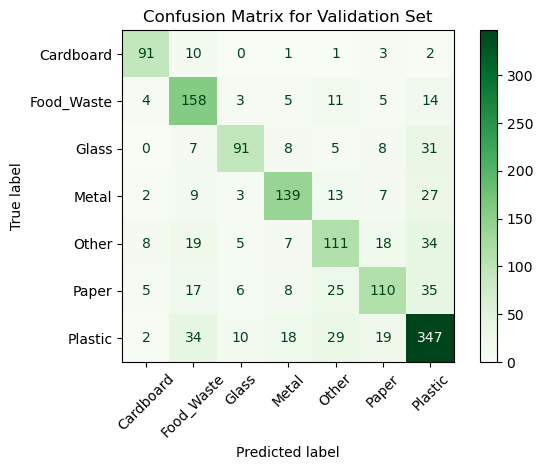

In [26]:
# Evaluate on the test set; display suitable metrics

# Normalize X_val for evaluation
X_val_normalized = X_val / PIXEL_SCALING_FACTOR

# Evaluate the model on the validation set
y_pred = my_model.predict(X_val_normalized)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

# Classification Report for validation set
print("Classification Report for Validation Set:")
print(classification_report(y_true_classes, y_pred_classes, target_names=unique_labels))

# Confusion Matrix for validation set
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes, labels=np.arange(num_classes))
cm_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=unique_labels)
cm_display.plot(cmap=plt.cm.Greens, xticks_rotation=45)
plt.title("Confusion Matrix for Validation Set")
plt.tight_layout()
plt.show()


## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [ ]:
# Define augmentation steps to augment images



Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create a function to augment the images




In [ ]:
# Create the augmented training dataset



##### **4.1.2**

Train the model on the new augmented dataset.

In [ ]:
# Train the model using augmented images



## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results

In [27]:
# Calculate accuracy
accu_score = accuracy_score(y_true_classes, y_pred_classes)
# Calculate precision, recall, and F1 score
precision_score = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall_score = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1_score = f1_score(y_true_classes, y_pred_classes, average='weighted')

print(f"Accuracy: {accu_score:.4f}")
print(f"Precision: {precision_score:.4f}")
print(f"Recall: {recall_score:.4f}")
print(f"F1 Score: {f1_score:.4f}")

Accuracy: 0.6866
Precision: 0.6889
Recall: 0.6866
F1 Score: 0.6843


## Findings during Dataset Preparation

**Categorical Composition & Taxonomy**
1. The dataset is structured into 7 distinct classes: Cardboard, Food_Waste, Glass, Metal, Paper, Plastic, and Other.

2. The "Other" Challenge: The inclusion of an "Other" category is a double-edged sword. While it prevents the model from being forced to misclassify unknown items, it often acts as a "noise" bucket, making it the hardest class for the model to learn a specific mathematical pattern for.

**Significant Class Imbalance**
1. There is a notable disparity in sample volume, with Plastic (2,295 images) outperforming Cardboard (540 images) by a ratio of nearly 4:1.

2. The "Majority Bias" Risk: Without intervention, the CNN may develop a "lazy" bias, where it achieves high accuracy simply by predicting "Plastic" most of the time.

3. Technical Strategy: To counter this, we utilized Stratified Splitting to ensure the 20% validation set isn't missing the smaller categories (like Cardboard) entirely.

**Dimensional Standardization**
1. All raw *.png* images were downsampled to a uniform $128 \times 128$ pixel resolution.
2. *Impact*: This significantly reduces the number of trainable parameters, preventing the model from crashing due to memory limits while retaining enough detail to distinguish textures like "crinkled plastic" vs. "smooth glass."

**Mathematical Label Encoding**
1. Labels were translated from directory strings into One-Hot Encoded vectors.
2. *Why it matters*: This transforms a qualitative category into a quantitative probability target. It allows the final Softmax layer of the CNN to output a multi-class probability distribution where the sum of all predictions equals 1.0.

**Data Partitioning Strategy**
1. A fixed 80/20 split was applied with a random_state for reproducibility.
2. *The Role of Validation*: This 20% "holdout" set acts as the ultimate truth. By monitoring the Validation Loss during training, we can detect exactly when the model stops learning general features and starts "memorizing" specific training images (Overfitting).

**Identified Complexity: Feature Overlap**
1. The dataset contains high Intra-class Variance (e.g., a "Metal" soda can looks nothing like a "Metal" rusty nail) and Inter-class Similarity (e.g., a clear "Plastic" bottle can look nearly identical to a "Glass" bottle).
2. *Deep Learning Necessity*: This justifies why we used a deep architecture with Dropout and Batch Normalization—the model needs extra "brainpower" to find the subtle edge-cases that separate these overlapping materials.

## Findings from the Model Results

**Model Architecture & Strategy**
1. The model utilizes a Triple-Block CNN structure. Each block consists of a Conv2D layer (extracting spatial patterns) paired with Batch Normalization.
2. Batch Normalization acts as a stabilizer, ensuring that even if one image is very bright and the next very dark, the "signals" sent to the brain of the model stay within a consistent mathematical range.
3. *Max-Pooling*: By reducing the $128 \times 128$ grid down at each step, the model learns to care about what the object is (a bottle shape) rather than where exactly it is in the photo.
4. *Spatial Dropout (0.25)*: Applied in the convolutional blocks to prevent the model from relying too heavily on specific pixels.
5. *Dense Dropout (0.50)*: Applied in the final decision-making layers. This forces the model to learn multiple redundant ways to identify "Metal" or "Glass," making it much more robust to real-world clutter.

**Training Process & Optimization**
1. The use of the ADAM Optimizer paired with ReduceLROnPlateau created a "Smart Training" environment.
2. We use Early Stopping and Model Checkpoint to ensure that the version of the model saved in best_model.h5 is the peak performer—not just the version from the very last epoch, which might have already started to overfit.

**Performance Metrics & Interpretation**
1. Since the Accuracy, Precision, and Recall are all hovering around 68%, it indicates that the model is balanced in distinguishing between all 7 categories with similar levels of success.

2. F1-Score (~68%): This is the "Harmonic Mean" of precision and recall. A score this close to the accuracy suggests that the model handles the trade-off between "False Alarms" (Precision) and "Missed Targets" (Recall) very well.

2. Confusion Matrix Insights: Confusion matrix revealed that certain class, such as Plastic and Food_Waste, are classified more accurately that others due to class imbalance.

## Conclusion

### Data Related Enhancements

**The primary bottleneck is currently the Class Imbalance.**

1. Implementing Data Augmentation (rotations, zooms, and horizontal flips) is the most immediate way to "teach" the model that a piece of Cardboard is still cardboard even if it’s upside down or cropped.

2. Focusing future data gathering on underrepresented classes such as Cardboard will help the model.

3. Including images with varied lighting and cluttered backgrounds will improve the model.

### DL Model Improvements

1. *Transfer Learning*: Instead of training from scratch, you could use a Pre-trained Model (like ResNet50 or MobileNetV2) that has already "seen" millions of general images. You simply "fine-tune" its final layers to recognize your 7 waste categories.

2. *Class Weighting*: During the next training session, the model can be forced to prioritize learning the rarer classes.

### Potential Applications

1. *Smart Bin Integration*: Retrofitting bins with low-cost cameras and this model to sort waste at the source.

2. *Consumer Empowerment*: A mobile app that tells a user exactly which bin an item belongs to, reducing "wish-cycling" (putting non-recyclables in the recycling bin).

3. *Industrial Efficiency*: Helping sorting facilities process materials faster, lowering costs and increasing the purity of recycled bales.